# Exploratory Data Analysis (EDA)

In [1]:
#| output: false

import sys
from pathlib import Path
# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)


Project root: c:\Users\joetn\Real-Time_IoT_2022_Quantized_Auto_Encoder


In [2]:
from src.load_data import load_raw
from src.eda import effect_size
from src.eda import evaluate_kmeans_k, plot_k_diagnostics, choose_k_gap_rule, fit_kmeans, pca_project, plot_clusters_pca
from src.preprocessing import preprocess_categorical_ports
from src.preprocessing import PreprocessConfig, prepare_matrix


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
#| output: false

# Load dataset and save to data/raw
X, y, df = load_raw(fmt="csv")

df.head()

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,target
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502,MQTT_Publish


## Initial Data Validation & Skewness Check

1. **Absence of Amazon_Alexa normal traffic**: During dataset initialization and validation as shown in @tbl-rtiot-shapes, @tbl-rtiot-missing, and @tbl-rtiot-target-dist, we observed that the **Amazon_Alexa traffic category was entirely absent** from the available RT-IoT data. According to the original dataset documentation, Amazon_Alexa represents a normal traffic class containing approximately 86,842 observations and plays an important role in balancing the distribution between normal and attack traffic as shown in @tbl-rtiot-target-binary. Its absence substantially **reduces the volume of normal samples**, creating challenges for the intended anomaly detection framework, particularly for autoencoder training, which relies exclusively on learning normal traffic behavior.

    Because our intrusion detection dataset capture complex relationships across 83 network-flow features, **generating synthetic traffic (data augmentation) that preserves realistic temporal and statistical structure would be difficult** and could introduce artificial patterns. After unsuccessful attempts to obtain the complete dataset, we therefore refine the project scope to focus on IoT device traffic excluding the original voice-assistant (Amazon_Alexa) normal class. We will address the class imbalance for each modeling technique in their respective section.

2. **Categorical Feature Inspection:** From a data type audit in @tbl-rtiot-dtype-summary and @tbl-rtiot-string-features, we identified two string-based features within the dataset: `proto` and `service`. Both variables represent low-cardinality categorical attributes rather than identifiers. This suggests that these features encode meaningful protocol and network service information rather than sample-specific identifiers that could introduce data leakage.

3. **Analysis of Feature Skewness:** Feature skewness was evaluated across all numeric variables to identify the need for log transformation. @tbl-rtiot-skewness-summary and @fig-rtiot-skewness-distribution identified extreme skewness in the dataset with **66 numeric features with skewness over 2.0** indicating that **log transformation is necessary** before modeling. Such skewed distributions are expected in real-world network telemetry, where most flows are small while a minority of flows generate disproportionately large traffic volumes. After log transformation, we can observe in @tbl-rtiot-skewness-summary-log that **skewness levels drop significantly** and it's safe to assume that long tails are compressed and variances stabilized.

In [4]:
# Establish variables for later use
RANDOM_STATE = 42
NORMAL_CLASSES = {"Thing_Speak", "MQTT_Publish", "Wipro_bulb"}
TARGET_COL = "target"
CAT_COLS = ["service", "proto", "id.resp_p"]

# Set plt plotting configs
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,
    "legend.frameon": True,
    "legend.borderpad": 0.3
})

# Focus on numeric features for correlation annd plotting
X_num = (
    df
    .drop(columns=[TARGET_COL] + CAT_COLS)
    .select_dtypes(include=[np.number])
)
NUMERIC_FEATURES = X_num.columns.tolist()

# Create masks for normal vs attack classes
NORMAL_MASK = df[TARGET_COL].isin(NORMAL_CLASSES)
ATTACK_MASK = ~NORMAL_MASK

In [5]:
#| label: tbl-rtiot-shapes
#| tbl-cap: "Summary of feature matrix (X) and target vector (y) dimensions for the dataset, including a sample of feature column names."

shape_summary_df = pd.DataFrame({
    "Property": [
        "X shape",
        "y shape",
        "First 5 X columns",
        "y column name"
    ],
    "Value": [
        X.shape,
        y.shape,
        list(X.columns)[:5],
        y.name
    ]
})

display(shape_summary_df.style.hide(axis="index"))


Property,Value
X shape,"(123117, 83)"
y shape,"(123117,)"
First 5 X columns,"['id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration']"
y column name,target


In [6]:
#| label: tbl-rtiot-missing
#| tbl-cap: "Summary of missing values in the feature matrix (X) and target vector (y), including total counts and missing-value rates."

dataset_missing = pd.DataFrame({
    "dataset": ["X (features)", "y (target)"],
    "missing_values": [X.isna().sum().sum(), y.isna().sum()],
    "missing_rate": [
        X.isna().sum().sum() / X.size,
        y.isna().sum() / len(y)
    ]
})

display(dataset_missing.style.hide(axis="index"))

dataset,missing_values,missing_rate
X (features),0,0.000000
y (target),0,0.000000


In [7]:
#| label: tbl-rtiot-target-dist
#| tbl-cap: "Distribution of target classes in the dataset, including class counts and relative frequencies."

target_counts = (
    y.value_counts()
    .rename_axis("target")
    .to_frame("count")
)

target_counts["rate"] = target_counts["count"] / target_counts["count"].sum()
display(target_counts)

,count,rate
target,,
DOS_SYN_Hping,94659,0.768854
Thing_Speak,8108,0.065856
ARP_poisioning,7750,0.062948
MQTT_Publish,4146,0.033675
NMAP_UDP_SCAN,2590,0.021037
NMAP_XMAS_TREE_SCAN,2010,0.016326
NMAP_OS_DETECTION,2000,0.016245
NMAP_TCP_scan,1002,0.008139
DDOS_Slowloris,534,0.004337


In [8]:
#| label: tbl-rtiot-target-binary
#| tbl-cap: "Binary target label distribution (0=normal, 1=attack)."

# 1 = attack, 0 = normal
y_bin = (~y.isin(NORMAL_CLASSES)).astype(int)

# Build a single clean summary table
class_counts = y_bin.value_counts().sort_index().rename_axis("class").to_frame("count")
class_counts["rate"] = class_counts["count"] / class_counts["count"].sum()

display(class_counts)


,count,rate
class,,
0,12507,0.101586
1,110610,0.898414


In [9]:
#| label: tbl-rtiot-dtype-summary
#| tbl-cap: "Data type summary of feature matrix (X) (excluding target column)."

dtype_summary = (
    X.dtypes
        .value_counts()
        .rename_axis("dtype")
        .reset_index(name="count")
)

display(dtype_summary.style.hide(axis="index"))

dtype,count
float64,47
int64,34
str,2


In [10]:
#| label: tbl-rtiot-string-features
#| tbl-cap: "String features and their unique values."

STR_COLS = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

string_cardinality = (
    df[STR_COLS]
    .nunique()
    .sort_values(ascending=False)
    .rename("unique_values")
    .rename_axis("string_feature")
    .reset_index()
)

display(string_cardinality.style.hide(axis="index"))

string_feature,unique_values
service,10
proto,3


In [11]:
#| label: tbl-rtiot-skewness-summary
#| tbl-cap: "Summary of skewness statistics across numeric features before log transformation"

skewness = (
    X_num.skew(numeric_only=True)
        .abs()
        .sort_values(ascending=False)
)

skew_summary = pd.DataFrame({
    "total_numerical_features": [len(skewness)],
    "skewness > 2": [(skewness > 2).sum()],
    "skewness > 5": [(skewness > 5).sum()],
    "max_skewness": [skewness.max()],
    "median_skewness": [skewness.median()]
})

display(skew_summary.style.hide(axis="index"))

total_numerical_features,skewness > 2,skewness > 5,max_skewness,median_skewness
80,65,61,340.497528,29.228034


In [12]:
#| label: tbl-rtiot-skewness-summary-log
#| tbl-cap: "Summary of skewness statistics across numeric features after log transformation"

X_num_log = np.log1p(X_num)
skewness_log = (
    X_num_log.skew(numeric_only=True)
        .abs()
        .sort_values(ascending=False)
)

skew_summary = pd.DataFrame({
    "total_numerical_features": [len(skewness_log)],
    "skewness > 2": [(skewness_log > 2).sum()],
    "skewness > 5": [(skewness_log > 5).sum()],
    "max_skewness": [skewness_log.max()],
    "median_skewness": [skewness_log.median()]
})

display(skew_summary.style.hide(axis="index"))

total_numerical_features,skewness > 2,skewness > 5,max_skewness,median_skewness
80,61,11,45.880008,2.639468


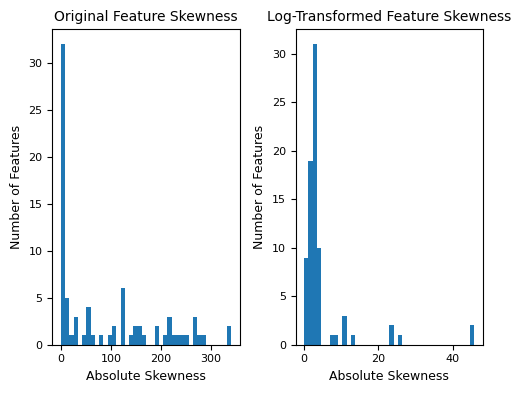

In [13]:
#| label: fig-rtiot-skewness-distribution
#| fig-cap: "Distribution of feature skewness before and after log transformation."

fig, axes = plt.subplots(1, 2, figsize=(5,4))

# Original skewness
axes[0].hist(skewness, bins=40)
axes[0].set_title("Original Feature Skewness")
axes[0].set_xlabel("Absolute Skewness")
axes[0].set_ylabel("Number of Features")

# Log-transformed skewness
axes[1].hist(skewness_log, bins=40)
axes[1].set_title("Log-Transformed Feature Skewness")
axes[1].set_xlabel("Absolute Skewness")
axes[1].set_ylabel("Number of Features")

plt.tight_layout()
plt.show()

## Identifying Class-Separating Features

To better understand which features better distinguish normal and attack traffic, we rank original-scale features using a **Standardized Mean Difference (SMD)** measure aka Cohen's d, a filter-based feature selection approach that quantifies class separability independent of model assumptions (Cohen, 1988).

For each **numeric feature**, we compute a standardized difference between the normal and attack distributions:

$$
d = \frac{|\mu_{\text{normal}} - \mu_{\text{attack}}|}{\sigma_{\text{pooled}}}
$$

where the pooled standard deviation summarizes variability across both classes:

$$
\sigma_{\text{pooled}} =
\sqrt{\frac{\sigma_{\text{normal}}^{2} + \sigma_{\text{attack}}^{2}}{2}}
$$

And:

- $\mu_{\text{normal}}$ — mean feature value for normal traffic  
- $\mu_{\text{attack}}$ — mean feature value for attack traffic  
- $\sigma_{\text{pooled}}$ — pooled standard deviation across both classes  
- $d$ — standardized separation (effect size)

This metric quantifies how strongly a feature separates the two binary classes independent of scale. Features with larger effect sizes indicate **greater distributional separation between normal and attack traffic** and are therefore more informative for visualization and downstream modeling analysis as shown in @tbl-rtiot-effect-sizes (Cohen, 1988).

The top-ranked features are selected as **class-separating features** and used in the following exploratory visualizations and analysis.

In [14]:
#| label: tbl-rtiot-effect-sizes
#| tbl-cap: "Top 10 features by effect size (numeric only)"

TOP_K = 10
EPS = 1e-12   # small stabilizer

# Calculate effect size
effect_size = effect_size(df, NORMAL_MASK, ATTACK_MASK, eps=EPS)

effect_scores = (
    X_num.columns.to_series()
    .apply(effect_size)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values(ascending=False)
)

TOP_FEATURES = effect_scores.head(TOP_K).index

display(
    effect_scores.head(10)
        .rename("Standardized Mean Difference")
        .rename_axis("Features")
        .reset_index()
)

,Features,Standardized Mean Difference
0,fwd_pkts_payload.min,2.738131
1,fwd_pkts_payload.avg,2.140473
2,fwd_init_window_size,1.666699
3,fwd_pkts_per_sec,1.493684
4,flow_pkts_per_sec,1.493501
5,bwd_pkts_per_sec,1.493306
6,bwd_init_window_size,1.471090
7,payload_bytes_per_second,1.435030
8,active.min,1.054205
9,fwd_subflow_pkts,0.965146


## Analysis of Class-Separating Features

To better understand how normal and attack traffic differ, kernel density estimates (KDEs) were plotted in @fig-rtiot-kde for the top 10 class-separating features identified using standardized mean difference (SMD) above. These visualizations compare the empirical distributions of normal and attack samples for each feature.

1. **Clear Distributional Separation**:

    Across multiple features, attack traffic exhibits distinct statistical behavior compared to normal traffic. In particular:

    - Packet-rate features (`*_pkts_per_sec`, `flow_pkts_per_sec`, `bwd_pkts_per_sec`) show strong magnitude shifts between classes.
    - Payload statistics (`fwd_pkts_payload.min`, `fwd_pkts_payload.avg`, `payload_bytes_per_second`) demonstrate highly concentrated attack distributions with limited overlap.
    - TCP window size features (`*_init_window_size`) reveal substantially different operating ranges between normal and attack traffic.
    - Flow activity and subflow metrics (`active.min`, `fwd_subflow_pkts`) further distinguish attack behavior through tightly clustered value regions.

    In many cases, the **attack distribution forms an extremely narrow peak while normal traffic remains broader and multimodal**, indicating reduced variability within attack-generated flows.

2. **Behavioral Differences in Network Traffic**:

    The observed separation suggests that attacks modify fundamental traffic dynamics rather than subtle statistical properties. Specifically, attack flows tend to exhibit:

    - highly regular packet transmission rates,
    - consistent payload characteristics,
    - constrained TCP window configurations, and
    - structured subflow behavior.

    These patterns are consistent with **automated or scripted attack generation**, which produces repeatable traffic signatures compared to naturally varying user-driven network activity.

3. **Low Overlap Between Classes**:

    Several features display near-disjoint density regions, with attack samples concentrated within narrow intervals while normal traffic spans a wider range of values. This indicates that **individual features already encode strong discriminatory signal**, reducing reliance on complex feature interactions or nonlinear transformations for class separation.

4. **Implications for Downstream Modeling**:

    The presence of strong class separation at the feature level suggests that **linear decision boundaries may capture much of the discriminative structure** present in the dataset. Consequently, a simple supervised baseline model is well justified before introducing more complex representation-learning approaches such as autoencoders.

    Importantly, these findings reflect meaningful behavioral differences between normal and attack traffic patterns captured by the RT-IoT 2022 dataset rather than evidence of data leakage.

    Overall, the exploratory analysis demonstrates that a subset of packet-rate, payload, window-size, and flow-activity features provides substantial statistical separation between classes. These results establish an empirical foundation for subsequent modeling experiments and help explain why relatively simple classifiers may achieve strong performance on this dataset.

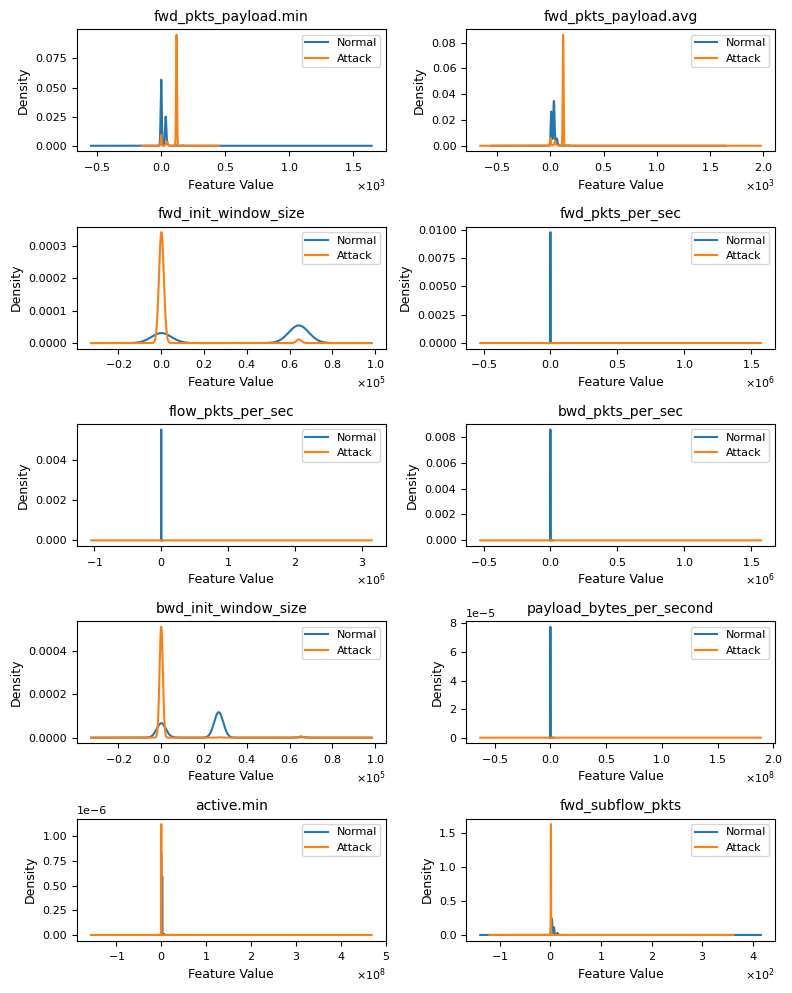

In [15]:
#| label: fig-rtiot-kde
#| fig-cap: "KDE plots of top features by effect size"

fig, axes = plt.subplots(5, 2, figsize=(8, 10))
axes = axes.flatten()

for ax, col in zip(axes, TOP_FEATURES):

    df.loc[NORMAL_MASK, col].plot(kind="kde", ax=ax, label="Normal")
    df.loc[ATTACK_MASK, col].plot(kind="kde", ax=ax, label="Attack")

    # Titles and labels
    ax.set_title(col)
    ax.set_xlabel("Feature Value")
    ax.set_ylabel("Density")

    # Improve tick readability for large network values
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0,0))

    ax.legend()

plt.tight_layout()
plt.show()

## Correlation & Multicollinearity Analysis

@fig-rtiot-corr-heatmap presents the Pearson correlation matrix for the top 10 class-separating original-scale numeric features identified above. The heatmap reveals several clear structural patterns that provide insight into multicollinearity and behavioral groupings within the RT-IoT 2022 dataset. @tbl-rtiot-vif-summary also show that many of their VIF scores are extreme. **68 numeric features carry extreme multicollinearity** (VIF > 10). 

These observations enable the following interpretations:

1. **Strong Feature Clustering and Redundancy:**

    The most prominent observation in the heatmap is the presence of distinct blocks of highly correlated features (correlation coefficients approaching ±1). These clusters indicate that multiple variables capture closely related aspects of the same underlying network behavior rather than independent signals.

    In particular:

    - Packet-rate features (`*_pkts_per_sec`) exhibit near-perfect positive correlation with one another, suggesting they are derived from common traffic counters.
    - Inter-arrival time statistics (`flow_iat.*`, `fwd_iat.*`, `idle.*`) form a dense correlation block, reflecting shared temporal characteristics of network flows.
    - Payload and header-size measurements also display moderate-to-strong correlations, indicating overlapping representations of packet structure.

    This redundancy implies that many high-ranking features encode similar information about traffic intensity and timing dynamics.

2. **Behavioral Grouping of Network Characteristics**:

    The correlation structure naturally separates features into interpretable behavioral categories:

    - **Transmission intensity:** packet rates and payload throughput metrics.
    - **Temporal dynamics:** inter-arrival times, idle durations, and activity statistics.
    - **Protocol and structural properties:** window sizes and header-related features.

    These groupings suggest that attack behavior manifests through coordinated changes across multiple related measurements rather than isolated feature shifts.

3. **Limited Independence Among Top Predictors:** Relatively few features (12) appear statistically independent (VIF $ \leq $ 10). High correlations indicate substantial multicollinearity, meaning that including many correlated variables may not significantly increase predictive power but can increase model complexity and computational cost. 

4. **Implications for Feature Selection and Modeling:** The observed correlation structure supports the use of feature reduction prior to deployment. Because many variables measure similar traffic properties, a smaller subset of representative features can likely preserve most predictive information while improving efficiency. For linear models such as Logistic Regression, correlated predictors are partially mitigated through L2 regularization; however, reducing redundancy remains **beneficial for interpretability and resource-constrained deployment** scenarios.

5. **Connection to Dataset Characteristics:** The clustered correlations reflect the engineered nature of network-flow datasets, where multiple statistics are computed from the same packet stream. As a result, these **high correlation does not indicate noise but rather repeated measurements** of shared underlying traffic processes. Overall, the correlation analysis demonstrates that the RT-IoT 2022 dataset contains strong but highly redundant signals, reinforcing the motivation for dimensionality reduction and efficient feature selection in subsequent modeling stages.

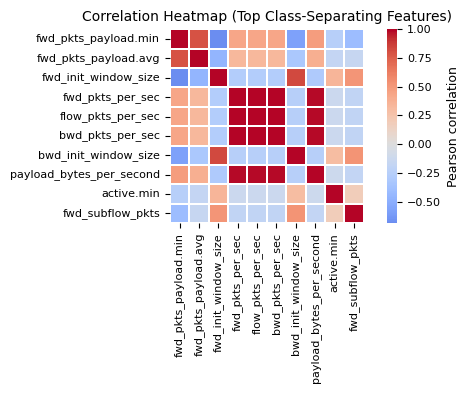

In [16]:
#| label: fig-rtiot-corr-heatmap
#| fig-cap: "Correlation heatmap of top 10 class-separating numeric features (by effect size)"

CORR_TOP_K = 10

CORR_FEATURES = (
    effect_scores
        .head(CORR_TOP_K)
        .index
)

corr = X_num[CORR_FEATURES].corr(method="pearson")

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"label": "Pearson correlation"}
)

plt.title("Correlation Heatmap (Top Class-Separating Features)")
plt.tight_layout()
plt.show()

In [17]:
#| label: tbl-rtiot-vif-summary
#| tbl-cap: "Variance Inflation Factor (VIF) summary for numeric features"

# Copy numeric features for VIF calculation
X_vif = X_num.copy()

# Drop constant columns
X_vif = X_vif.loc[:, X_vif.nunique() > 1]

# Drop duplicate columns
X_vif = X_vif.loc[:, ~X_vif.T.duplicated()]

# Replace inf values if any
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

# Scale features for VIF stability
X_vif_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_vif),
    columns=X_vif.columns,
    index=X_vif.index
)

# Calculate VIF for each feature
vif_df = pd.DataFrame({
    "feature": X_vif_scaled.columns,
    "VIF": [
        variance_inflation_factor(X_vif_scaled.values, i)
        for i in range(X_vif_scaled.shape[1])
    ]
}).sort_values("VIF", ascending=False)


# Split by VIF threshold
vif_high = vif_df[vif_df["VIF"] > 10].copy()
vif_acceptable = vif_df[vif_df["VIF"] <= 10].copy()

# Setup table for display
vif_summary_df = (
    pd.DataFrame({
        "Number of Features": [
            len(vif_high),
            len(vif_acceptable)
        ]
    },
    index=[
        "High multicollinearity (VIF > 10)",
        "Acceptable multicollinearity (VIF <= 10)"
    ])
    .rename_axis("VIF Category")
)

display(vif_summary_df)

,Number of Features
VIF Category,
High multicollinearity (VIF > 10),68
Acceptable multicollinearity (VIF <= 10),11


## Mutual Information Analysis

To quantify the predictive relevance of the features, **mutual information (MI)** was computed between each log-scale numeric feature and the binary class labels. MI measures how much knowing a feature reduces uncertainty about class membership, capturing both linear and nonlinear dependencies between network traffic characteristics and attack vs. normal behavior (Peng et al., 2005).

MI quantifies statistical dependence between a feature $X$ and the target class $y$:

$$
I(X;Y)=\sum_{x,y} p(x,y)\log\frac{p(x,y)}{p(x)p(y)}.
$$

It can also be interpreted as a reduction in uncertainty:

$$
I(X;Y)=H(Y)-H(Y|X),
$$

where $H(Y)$ denotes entropy and $H(Y|X)$ represents conditional entropy. A value of $I(X;Y)=0$ implies statistical independence between $X$ and $Y$. Because MI captures both linear and nonlinear relationships, it is well suited for network traffic analysis, where attack behavior may alter packet statistics in complex, non-linear ways (Peng et al., 2005).

The top predictive features ranked by mutual information, as shown in @fig-rtiot-mi, are:

- fwd_pkts_payload.max
- fwd_subflow_bytes
- fwd_pkts_payload.avg
- flow_pkts_payload.tot
- fwd_pkts_payload.tot
- flow_pkts_payload.max
- flow_pkts_payload.avg
- fwd_last_window_size

From this MI analysis, we can make the following interpretations:

1. **Strong Predictive Signal:**

    All selected features exhibit **high mutual information scores (approximately 0.80–0.88)**, indicating that individual variables contain substantial information about whether a network flow corresponds to normal or attack traffic. The strength of these scores suggests that meaningful class separation exists directly at the feature level, rather than requiring complex nonlinear feature interactions to distinguish traffic behavior. This indicates that the RT-IoT dataset contains strong statistical signatures of attack activity, enabling relatively simple models to exploit clear differences between traffic patterns.

2. **Dominance of Payload-Based Traffic Characteristics:**

    Most of the highest-ranked features are derived from packet payload statistics, including averages, maxima, and total payload sizes. These features capture the volume and structure of transmitted data within a flow, which appears to differ consistently between normal and malicious attack activity. The concentration of payload-related features among the top predictors indicates that attacks modify fundamental transmission behavior. Compared to normal traffic, attack flows tend to exhibit:

    - more uniform/consistent payload sizes,
    - structured packet transmission patterns,
    - and reduced variability across packets within a flow.

    Such regularity is characteristic of **automated attack tools, which generate traffic programmatically rather than through organic user-driven interactions**.

3. **Evidence of Feature Redundancy:**

    Several top features measure closely related quantities (e.g., average, maximum, and total payload statistics). While each individually shows strong predictive power, their similarity suggests substantial redundancy as discussed in our VIF section above. This implies that **increasing the number of included features beyond the highest-ranked subset may provide diminishing returns**, as additional variables often encode overlapping information about the same traffic behavior.

4. **Flow-Level and Transport-Level Behavior Indicators:**

    The feature **fwd_subflow_bytes** captures flow-level transmission behavior, measuring the total number of bytes transmitted within forward-direction subflows. This metric reflects how data is aggregated and transmitted during bursts of communication within a flow. Its high mutual information score suggests that attack traffic often exhibits **distinct burst-level transmission patterns**, potentially due to automated tools generating packets in structured or repetitive sequences.

    The presence of **fwd_last_window_size** among the top predictive features further highlights the role of transport-layer characteristics in distinguishing traffic classes. TCP window size reflects how endpoints regulate data transmission and deviations in this parameter may indicate abnormal communication patterns associated with attack activity or automated traffic generation. Although payload statistics dominate the MI rankings, the inclusion of both fwd_last_window_size and fwd_subflow_bytes demonstrates that transport-layer dynamics and flow-level transmission structure also contribute meaningful information for intrusion detection, complementing the packet-level payload features.

5. **Implications for Downstream Model Selection:**

    The presence of highly informative features imply a strong performance with linear classifiers such as Logistic Regression. Because **substantial class separation exists at the feature level**, complex nonlinear models are not strictly required to achieve strong discrimination performance. From a practical standpoint, these findings suggest that a **compact subset of high-MI features may be sufficient for effective intrusion detection while reducing computational cost**. Overall, the mutual information analysis indicates that payload dynamics and flow-level transmission characteristics constitute the primary statistical signatures distinguishing normal and attack traffic in the RT-IoT dataset.

In [18]:
# Calculate mutual information scores for numeric features
mi_scores = mutual_info_classif(
    X_num_log,
    y,
    random_state=RANDOM_STATE,
    discrete_features=False
)

mi_series = pd.Series(mi_scores, index=X_num.columns)\
                .sort_values(ascending=False)

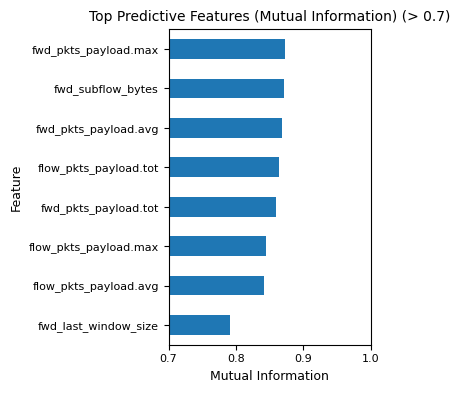

In [19]:
#| label: fig-rtiot-mi
#| fig-cap: "Top 8 log-scaled features ranked by mutual information (MI) with the target class label."
#| echo: false

plt.figure(figsize=(4,4))

mi_series.head(8).iloc[::-1].plot(kind="barh")

# Zoom into high-MI region
plt.xlim(0.7, 1.0)

plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Top Predictive Features (Mutual Information) (> 0.7)")
plt.tight_layout()
plt.show()

## Addressing Categorical Features

The dataset contains several categorical attributes, including service, protocol (proto), and response port identifiers (id.resp_p), which cannot be directly used in distance-based analyses such as PCA or clustering. To incorporate these variables into the modeling pipeline, we performed a structured feature engineering process.

First, the response port feature was **transformed into service-based port groups to reduce its high cardinality** while preserving meaningful network semantics. Ports associated with common application-layer services (e.g., web, DNS, MQTT, SSH) were grouped into dedicated categories, while remaining ports were categorized as either well-known ports or high-numbered ephemeral ports. The resulting distribution shows that FTP-related traffic dominates the dataset (94,672), followed by high ports (8,603), and DNS (7,210) as shown in @tbl-rtiot-port-group.

After grouping, the categorical variables (service, proto, and port_group) were **transformed using one-hot encoding**, allowing them to be incorporated into numerical analyses alongside the existing numerical features. The correlation heatmap of the encoded features in @fig-rtiot-cat-corr also reveals several expected relationships. 

Strong positive correlations appear between certain service indicators and their corresponding port groups, reflecting consistent mappings between application protocols and typical service ports (e.g., MQTT service with MQTT ports, DNS service with DNS ports). Conversely, negative correlations arise among mutually exclusive categories, particularly between protocol indicators such as TCP and UDP.

Overall, this preprocessing step preserves important categorical information while ensuring compatibility with downstream statistical analysis, dimensionality reduction, and clustering methods in the following section.

In [20]:
#| label: tbl-rtiot-port-group
#| tbl-cap: "Frequency distribution of grouped response port categories from id.resp_p"

X_cat, port_counts = preprocess_categorical_ports(df)

display(port_counts)

,port_group,count
0,ftp,94672
1,high_port,8603
2,dns,7210
3,web,6724
4,mqtt,4142
5,well_known_other,1548
6,ntp,121
7,ssh,62
8,mail,20
9,smtp,15


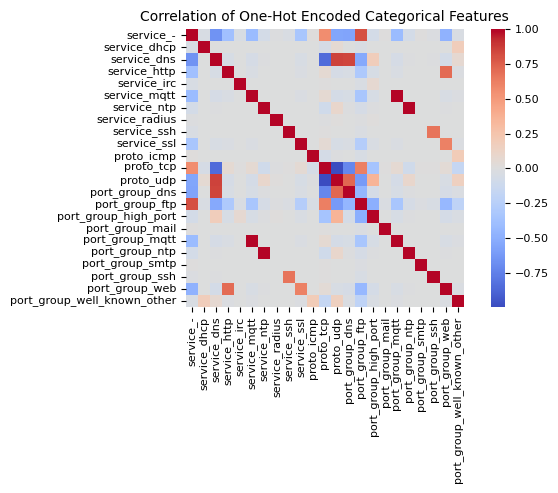

In [21]:
#| label: fig-rtiot-cat-corr
#| fig-cap: "Correlation matrix of one-hot encoded categorical features"

corr_cat = X_cat.corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr_cat,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation of One-Hot Encoded Categorical Features")
plt.tight_layout()
plt.show()

In [22]:
#| output: false

# Concatenate log-scale numeric X_num_log with one-hot encoded X_cat
X_all = pd.concat([X_num_log, X_cat], axis=1)
print(X_all.shape)
print(X_all.select_dtypes(include=["object"]).columns)

(123117, 103)
Index([], dtype='str')


## Principal Component Analysis (PCA)

Given the 103 features (80 numerical + 23 encoded) after categorical encoding, dimensionality-reduction techniques such as PCA can help analyze the structure of the feature space. Each principal component is a linear combination of the original features and is constructed to capture the maximum possible variance while remaining uncorrelated to other components (Russell & Norvig, 2021).

**PCA Mathematical Summary**:

We center the Data:
$$
\tilde{X}_{ij} = X_{ij} - \mu_j
$$ 
where $$ \mu_j = \frac{1}{n} \sum_{i=1}^{n} X_{ij} $$

Compute the Covariance Matrix:
$$
\Sigma = \frac{1}{n-1} \tilde{X}^T \tilde{X}
$$

Eigenvalue Decomposition:
$$
\Sigma v_k = \lambda_k v_k
$$

Project Data onto Principal Components:

$$
z_k = \tilde{X} v_k
$$

For the first $m$ components:
$$
Z = \tilde{X} V_m
$$

Derive the Explained Variance Ratio:
$$
\text{Explained Variance}_k =
\frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}
$$

Calculate the Cumulative Explained Variance:
$$
\text{Cumulative Variance}_m =
\sum_{k=1}^{m}
\frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}
$$

The first principal component (PC1) captures the largest amount of variance in the dataset, the second (PC2) captures the next largest amount while remaining independent of the first, and so on. As a result, PCA can often represent most of the information in a dataset using only a small number of components.

Conceptually, PCA enables **dimensionality reduction** while retaining most of the information, **handles multicollinearity**, can reduce noise when low-variance components are discarded, and allow for visualizations with a small number of principal components to **detect patterns, clusters, and anomalies** (Russell & Norvig, 2021).

After scaling the log-scaled numerical and encoded feature matrix (X), PCA was performed with respect to the binary class labels:

1. The 2-D PC projection in @fig-rtiot-pca explains approximately **52.1% of the total variance** (PC1 $ \approx $ 38.3%, PC2 $ \approx $ 13.7%). While this captures a substantial portion of the variability, the plot shows significant overlap between normal and attack traffic, indicating that the **main variance directions are not strongly aligned with class separation**. This is expected because PCA maximizes variance rather than discriminative power. Several elongated clusters and extreme points are also visible, suggesting **heterogeneous traffic patterns and potential anomalous behaviors** within the dataset.

2. The cumulative explained variance in @fig-rtiot-pca-variance provides stronger insight into the dataset structure. The curve shows that **roughly 20–25 principal components capture about 95% of the variance**, after which additional components contribute minimal new information. This indicates that although the dataset originally contains many features, its effective dimensionality is much lower, reflecting **substantial correlation and shared structure** among network flow features. For modeling, this suggests that moderate dimensionality reduction may retain most of the information while improving model efficiency and reducing multicollinearity.

In [23]:
# Standardize features 
X_all_scaled = StandardScaler().fit_transform(X_all)

# PCA (2D projection)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_all_scaled)

evr_2d = pca_2d.explained_variance_ratio_

pca_2d_df = pd.DataFrame(
    {"PC1": X_pca_2d[:, 0], "PC2": X_pca_2d[:, 1], "binary_target": y_bin.values},
    index=X_num.index
)
# display(pca_2d_df)

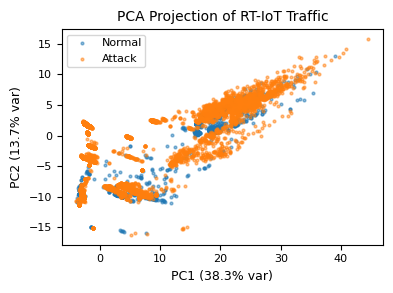

In [24]:
#| label: fig-rtiot-pca
#| fig-cap: "PCA projection (2D) on log-scale colored by normal vs attack classes. Explained variance ratios for PC1 and PC2 are indicated in the axis labels."

# PCA scatter plot
plt.figure(figsize=(4, 3))

plt.scatter(
    pca_2d_df.loc[NORMAL_MASK, "PC1"],
    pca_2d_df.loc[NORMAL_MASK, "PC2"],
    s=4, alpha=0.5, label="Normal"
)

plt.scatter(
    pca_2d_df.loc[ATTACK_MASK, "PC1"],
    pca_2d_df.loc[ATTACK_MASK, "PC2"],
    s=4, alpha=0.5, label="Attack"
)

plt.xlabel(f"PC1 ({evr_2d[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({evr_2d[1]*100:.1f}% var)")
plt.title("PCA Projection of RT-IoT Traffic")
plt.legend()
plt.tight_layout()
plt.show()

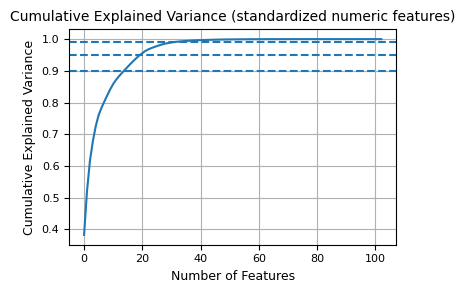

In [25]:
#| label: fig-rtiot-pca-variance
#| fig-cap: "Cumulative explained variance of traffic features. Horizontal dashed lines indicate common thresholds (90%, 95%, 99%) for intrinsic dimensionality estimation."

# Cumulative explained variance
pca_full = PCA().fit(X_all_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(4, 3))
plt.plot(cum)
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.axhline(0.99, linestyle="--")
plt.xlabel("Number of Features")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance (standardized numeric features)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Clustering Analysis

The last EDA performed is **unsupervised clustering** to explore whether natural groupings exist within the network traffic based on the full set of features. Instead of using normal or attack labels during training, clustering groups observations based solely on similarity in feature space, allowing us to examine the intrinsic structure of the data (Russell & Norvig, 2021).

1. Before clustering, numerical (including encoded) features are **down-sampled with uniform random sampling (n = 25,000) to reduce computational cost of clustering diagnostics** (e.g., Silhouette and Gap statistic) and standardized so that differences in scale do not disproportionately influence distance-based algorithms.

2. We then apply **K-means clustering** to partition the data into groups and evaluate cluster quality using several metrics: **Elbow (inertia), Silhouette score, Calinski–Harabasz (CH), and Gap statistic**.

The Gap statistic compares the within-cluster dispersion to that expected under a reference null distribution (Russell & Norvig, 2021):

$$
\text{Gap}(k) = \mathbb{E}_{n}^{*}[\log(W_k)] - \log(W_k)
$$

where $W_k$ is the within-cluster dispersion for k clusters and $\mathbb{E}_{n}^{*}$ denotes expectation under a reference distribution. The standard selection rule is:

$$
\text{Choose the smallest } k \text{ such that } \text{Gap}(k) \ge \text{Gap}(k+1) - s_{k+1}
$$

In our results from @fig-rtiot-kmeans-diag, the Gap statistic increases monotonically across all tested values of \(k\) and does not satisfy the stopping criterion. Therefore, the Gap statistic is unable to provide a clear recommendation for the optimal number of clusters.

Instead, the remaining diagnostics collectively suggest **\(k = 6\)** as a reasonable candidate:

- **Elbow curve:** inertia decreases rapidly until approximately \(k=6\), after which improvements diminish, indicating reduced marginal benefit from additional clusters.  
- **Silhouette score:** a substantial increase occurs at \(k=6\), followed by only marginal improvements, suggesting improved cluster separation around this value.  
- **Calinski–Harabasz score:** while the global maximum occurs at \(k=2\), a secondary local peak near \(k=6\) indicates a potentially meaningful cluster structure beyond the trivial two-cluster solution.

Together, these diagnostics suggest that **six clusters capture meaningful structure** in the feature space without over-fragmenting the data. The resulting clusters are visualized in @tbl-rtiot-kmeans-summary using the first two principal components similar to the previous section. Although the projection captures only about **~52% of the total variance (PC1 $ \approx $ 38.2%, PC2 $ \approx $ 13.5%)**, several patterns emerge:

- Several compact clusters near the center of the projection likely correspond to common traffic patterns shared across many observations.
- More isolated clusters and sparse regions suggest rare or specialized traffic behaviors, potentially corresponding to different attack techniques.
- Cluster boundaries do not align clearly with the normal/attack labels, reinforcing the earlier observation that dominant variance patterns primarily reflect **differences among attack behaviors rather than simple benign vs. malicious separation**.

Because the Amazon Alexa normal traffic is absent from the dataset, the class distribution is heavily skewed toward attack observations. As PCA maximizes overall variance and clustering algorithms group observations based on density, both analyses are driven largely by the dominant attack traffic patterns. Consequently, the clusters likely represent **different behavioral modes within attack traffic rather than a clear separation between normal and malicious activity**.

**Implications for Modeling**:

These exploratory results provide several useful insights for the next modeling phase:

- The dataset exhibits structured but overlapping regions in feature space, suggesting that simple linear separation may be insufficient for reliable classification.
- Clustering reveals multiple behavioral subgroups, indicating that intrusion patterns are heterogeneous i.e., there may not be a consistent pattern in attack traffic.
- Dimensionality-reduction and clustering both confirm that **complex relationships exist across many correlated features**, supporting the use of models capable of capturing nonlinear structure.

Together, these observations motivate the next phase of modeling, where we compare a baseline logistic regression classifier against more expressive models (e.g., autoencoders for anomaly detection) to determine whether reconstruction-based approaches better capture the complex structure of RT-IoT network traffic.

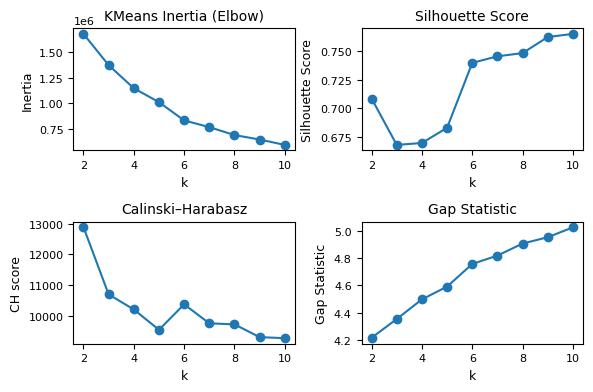

In [26]:
#| label: fig-rtiot-kmeans-diag
#| fig-cap: "K-means clustering diagnostics for selecting the number of clusters (k). The plots show inertia (Elbow method), Silhouette score, Calinski–Harabasz score, and Gap statistic across k = 2–10 using a random sample of 25,000 standardized observations from the log-scale feature matrix."

# Create a config object for settings
cfg = PreprocessConfig(sample_n=25000, scaler="standard", impute="median", random_state=RANDOM_STATE)

# Down sampling, impute missing values, and scale features
X_all_samp, idx = prepare_matrix(X_all, cfg)

# Set K range
k_range = range(2, 11)

# Fit K-Means, compute metrics (Elbow inertia, Silhouette score, CH score, and Gap statistic), store in table
k_metrics = evaluate_kmeans_k(X_all_samp, k_range, random_state=cfg.random_state, n_refs_gap=5)

plot_k_diagnostics(k_metrics)

In [30]:
#| label: tbl-rtiot-kmeans-summary
#| tbl-cap: "K-means clustering evaluation metrics across candidate cluster sizes (k = 2–10), including inertia, Silhouette score, Calinski–Harabasz score, and Gap statistic, computed on a standardized random sample (n = 25,000) of log-scale features."

display(k_metrics)

,k,inertia,silhouette,calinski_harabasz,gap,sk
0,2,1.682444e+06,0.708620,12890.283235,4.217992,0.002910
1,3,1.374337e+06,0.667950,10691.725066,4.355002,0.001564
2,4,1.146537e+06,0.669651,10199.105138,4.498236,0.001163
3,5,1.009605e+06,0.682985,9533.971663,4.591595,0.002265
4,6,8.295531e+05,0.739938,10367.232774,4.756633,0.002100
5,7,7.635888e+05,0.745672,9745.161692,4.817793,0.001572
6,8,6.854221e+05,0.748508,9712.373240,4.905605,0.001265
7,9,6.414672e+05,0.762593,9294.344757,4.951872,0.001778
8,10,5.882186e+05,0.765344,9260.525691,5.024099,0.001363


Gap-statistic suggested k: None


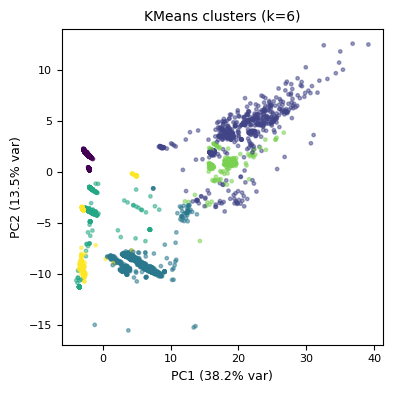

In [28]:
#| label: fig-rtiot-kmeans-pca
#| fig-cap: "K-means clustering results (k = 6) visualized using a 2-D PCA projection of the standardized, log-scale feature matrix. Colors indicate cluster membership, illustrating the structure of traffic behaviors in the first two principal components."

# Choose k based on gap statistic criterion. Return None if none qualifies
k_gap = choose_k_gap_rule(k_metrics[["k","gap","sk"]])
print("Gap-statistic suggested k:", k_gap)

# Fit KMeans
km, labels = fit_kmeans(X_all_samp, k=k_gap or 6, random_state=cfg.random_state)

# 2-D PCA projection
Z2, evr = pca_project(X_all_samp, n_components=2, random_state=cfg.random_state)
plot_clusters_pca(Z2, labels, evr, title=f"KMeans clusters (k={k_gap or 6})")

In [29]:
#| output: false

# Save X_all (log-scale numeric + encoded) and y_bin to data/processed for following modeling and analysis
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)
pd.DataFrame(X_all).to_csv(processed_dir / "X_all.csv", index=False)
pd.Series(y_bin, name="target").to_csv(processed_dir / "y_bin.csv", index=False)